# InterMeas internode-length measurement (Tabaracci et al., MethodsX 2024)

**Paper:** Tabaracci, K.; Bokros, N.; Oduntan, Y.; Kunduru, B.; DeKold, J.; Mengistie, E.; McDonald, A. G.; Stubbs, C. J.; Sekhon, R. S.; DeBolt, S.; Robertson, D. J. *Biomechanical phenotyping pipeline for stalk lodging resistance in maize.* **MethodsX** 12 (2024) 102562. doi:[10.1016/j.mex.2024.102562](https://doi.org/10.1016/j.mex.2024.102562) — open access (CC BY), PMCID PMC10825676.

**Author code:** [nbo245/InterMeas](https://github.com/nbo245/InterMeas) pinned at commit `f176cc0eb09b8e60048c12eb63c94773664866e6`.

**Scope (partial demonstration):** This notebook reproduces the paper's **internode-length image-analysis subsection** (paper phase *Internode lengths via YOLOv5 image analysis, InterMeas*) on the repository's own example stalk images: blue-backmat cropping → YOLOv5 node detection with the authors' bundled `best_nodes.torchscript` weight → conversion of node positions into per-internode lengths in centimeters with the authors' z-score outlier check. The **field/lab biomechanics phases** (DARLING bending, Instron puncture/micro-bending, chemistry) are out of scope: they require physical instruments and non-deposited data.

**実行範囲（部分的なデモ）:** 本notebookは論文の「節間長の画像解析（InterMeas）」サブセクションのみを、リポジトリ同梱のサンプル画像と学習済み重みで再現します。青色マットの切り出し → YOLOv5による節検出 → 節間長（cm）計算とZスコアによる外れ値チェックまでを行います。DARLINGやInstronなどの実機を要する工程は対象外です。

**Execution status:** CPU-only inference; the authors' README benchmark (2.2–2.5 s/image on desktop CPUs) makes GPU unnecessary.

**License note:** the InterMeas repository carries no license file (as of commit `f176cc0eb09b`); content is used here for scholarly attribution and demonstration only, and is not redistributed. The paper is open access CC BY.

## 1. Runtime selection

**Select `Runtime → Change runtime type → CPU`** (no GPU needed — the authors benchmark this weight at ~2.5 s/image on CPU). Then `Runtime → Run all`.

**ランタイム:** 「ランタイム → ランタイムのタイプを変更 → CPU」を選んでから「すべてのセルを実行」してください。CPU推論で十分です（著者らのベンチマーク：CPUで約2.5秒/画像）。全体で約5〜10分、ダウンロード約70 MB を見込んでいます。

Expected total time: ~5–10 min (dominated by the 43 MB weight download and 3 × ~9 MB images).

## 2. Environment check

This cell verifies the required packages on the Colab runtime. Colab preinstalls `torch`, `torchvision`, `opencv-python`, `pandas`, and `matplotlib`; the YOLOv5 hub package (`torch.hub.load('ultralytics/yolov5', ...)`) pulls its own pinned repository and needs only these preinstalled dependencies. The cell fails loudly if anything essential is missing.

**環境チェック:** 必要なパッケージ（torch / torchvision / OpenCV / pandas / matplotlib）がColabに揃っているかを確認します。GPUが割り当てられていても、本notebookはCPUで実行します。

In [ ]:
import torch, torchvision, cv2, pandas as pd, numpy as np, matplotlib
import matplotlib.pyplot as plt

print("torch", torch.__version__)
print("torchvision", torchvision.__version__)
print("opencv", cv2.__version__)
print("pandas", pd.__version__)
DEVICE = "cpu"  # faithful to the authors' --device cpu route; GPU is unnecessary here
print("Using device:", DEVICE)

torch 2.11.0+cpu
torchvision 0.26.0+cpu
opencv 4.14.0
pandas 2.2.3
Using device: cpu


## 3. Fetch pinned author inputs (inside Colab only)

**Purpose & provenance:** download the authors' bundled YOLOv5 torchscript weight and **three** example stalk images from the pinned commit `f176cc0eb09b` of `nbo245/InterMeas`. Three stalks (not one) are the minimum set because the authors' outlier check computes a z-score of each internode length *across stalks* (`helper_functions.R`, `analysis_function`), which needs more than one stalk per internode index. Each download is verified against the git blob SHA-1 recorded in the repository tree (`sha1("blob <size>\0" + content)`), so a wrong or corrupted file cannot pass silently.

**ピン留めしたコミットから重み（43 MB）とサンプル画像3枚（各約9 MB）をColab内で取得します。** サンプルは2枚以上必要です：著者のZスコア外れ値チェックは「節間ごとに茎間で標準化」するためです。各ファイルはリポジトリのツリーに記録されたgit blob SHA-1で検証します。

In [ ]:
import hashlib, pathlib, urllib.request

COMMIT = "f176cc0eb09b8e60048c12eb63c94773664866e6"
RAW = f"https://raw.githubusercontent.com/nbo245/InterMeas/{COMMIT}"

# git blob SHA-1s from the pinned repository tree (python3 tools/fetch_github_code.py, 2026-10-05)
REQUIRED = {
    "best_nodes.torchscript": "9e79ae5c43d27d79591a0f35635e268c031f8a22",
    "example_images/K21_408003-02__K21_408003-02__K21_408003-02.JPG": "9dd0a67d0750dfc1c5d5545ede47cffca4fb7cfd",
    "example_images/K21_408003-03__K21_408003-03__K21_408003-03.JPG": "52e46484318c705d4c08f5800a04cdc5b45de7c6",
    "example_images/K21_408003-04__K21_408003-04__K21_408003-04.JPG": "15d17ab3efdefecea1a7827accf12544a8165a3b",
}

def git_blob_sha1(data: bytes) -> str:
    return hashlib.sha1(b"blob %d\x00" % len(data) + data).hexdigest()

pathlib.Path("example_images").mkdir(exist_ok=True)
for rel, want in REQUIRED.items():
    dest = pathlib.Path(rel)
    if dest.exists() and git_blob_sha1(dest.read_bytes()) == want:
        print(f"cached OK  {rel}"); continue
    print(f"downloading {rel} ...", flush=True)
    urllib.request.urlretrieve(f"{RAW}/{rel}", dest)
    got = git_blob_sha1(dest.read_bytes())
    assert got == want, f"SHA mismatch for {rel}: {got} != {want}"
    print(f"blob SHA verified  {rel}  ({dest.stat().st_size:,} bytes)")

downloading best_nodes.torchscript ...


blob SHA verified  best_nodes.torchscript  (43,449,453 bytes)
downloading example_images/K21_408003-02__K21_408003-02__K21_408003-02.JPG ...


blob SHA verified  example_images/K21_408003-02__K21_408003-02__K21_408003-02.JPG  (8,921,469 bytes)
downloading example_images/K21_408003-03__K21_408003-03__K21_408003-03.JPG ...


blob SHA verified  example_images/K21_408003-03__K21_408003-03__K21_408003-03.JPG  (8,949,099 bytes)
downloading example_images/K21_408003-04__K21_408003-04__K21_408003-04.JPG ...


blob SHA verified  example_images/K21_408003-04__K21_408003-04__K21_408003-04.JPG  (8,900,509 bytes)


## 4. Crop the blue imaging mat (port of `cropper_v3.py`)

**Purpose:** the authors photograph each stalk on a standardized **36-inch-wide blue backmat**; `cropper_v3.py` isolates the mat by HSV color thresholding (blue hue 100–130) and cropping to the largest contour's bounding rectangle. This cell applies the exact same operation (`cv2.inRange` with the authors' thresholds `[100,50,50]–[130,255,255]`, largest-area contour, `boundingRect`) to each example image, sequentially instead of the authors' thread pool (3 images make threading unnecessary).

**青色マットの切り出し:** 論文の`cropper_v3.py`と同じHSV閾値（青色 100–130）で最大輪郭を求め、その外接矩形で画像を切り抜きます。3枚だけなので逐次処理にしています（数学的操作は同一）。

In [ ]:
import glob, os

# author thresholds from cropper_v3.py (commit f176cc0)
LOWER_BLUE = np.array([100, 50, 50])
UPPER_BLUE = np.array([130, 255, 255])

def crop_to_backmat(bgr):
    hsv = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV)
    mask = cv2.inRange(hsv, LOWER_BLUE, UPPER_BLUE)
    contours, _ = cv2.findContours(mask, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    c = max(contours, key=cv2.contourArea)          # largest contour = the blue mat
    x, y, w, h = cv2.boundingRect(c)
    return bgr[y:y+h, x:x+w]

os.makedirs("Resized_Outputs", exist_ok=True)
cropped = {}
for img_path in sorted(glob.glob("example_images/*.JPG")):
    bgr = cv2.imread(img_path, cv2.IMREAD_COLOR)
    assert bgr is not None, f"unreadable image: {img_path}"
    mat = crop_to_backmat(bgr)
    out = os.path.join("Resized_Outputs", os.path.splitext(os.path.basename(img_path))[0] + "_cropped.jpg")
    cv2.imwrite(out, mat)  # same output naming convention as cropper_v3.py
    cropped[out] = mat
    print(f"{os.path.basename(img_path)}: {bgr.shape[1]}x{bgr.shape[0]} -> cropped {mat.shape[1]}x{mat.shape[0]}")

K21_408003-02__K21_408003-02__K21_408003-02.JPG: 6000x4000 -> cropped 2896x3814


K21_408003-03__K21_408003-03__K21_408003-03.JPG: 6000x4000 -> cropped 2897x3814


K21_408003-04__K21_408003-04__K21_408003-04.JPG: 6000x4000 -> cropped 2896x3814


### 4b. Preview the cropped inputs

**Purpose:** human-readable check that the crop landed on the mat and the stalks are upright, before spending time on detection. The mat width (horizontal extent of this crop) is the physical scale reference (36 in = 91.44 cm) used later.

**切り抜きの確認:** 切り抜きがマットに正しく収まっているか、茎が纵向きかを確認します。この横幅が後ほど「36インチ = 91.44 cm」の物差しとして使われます。

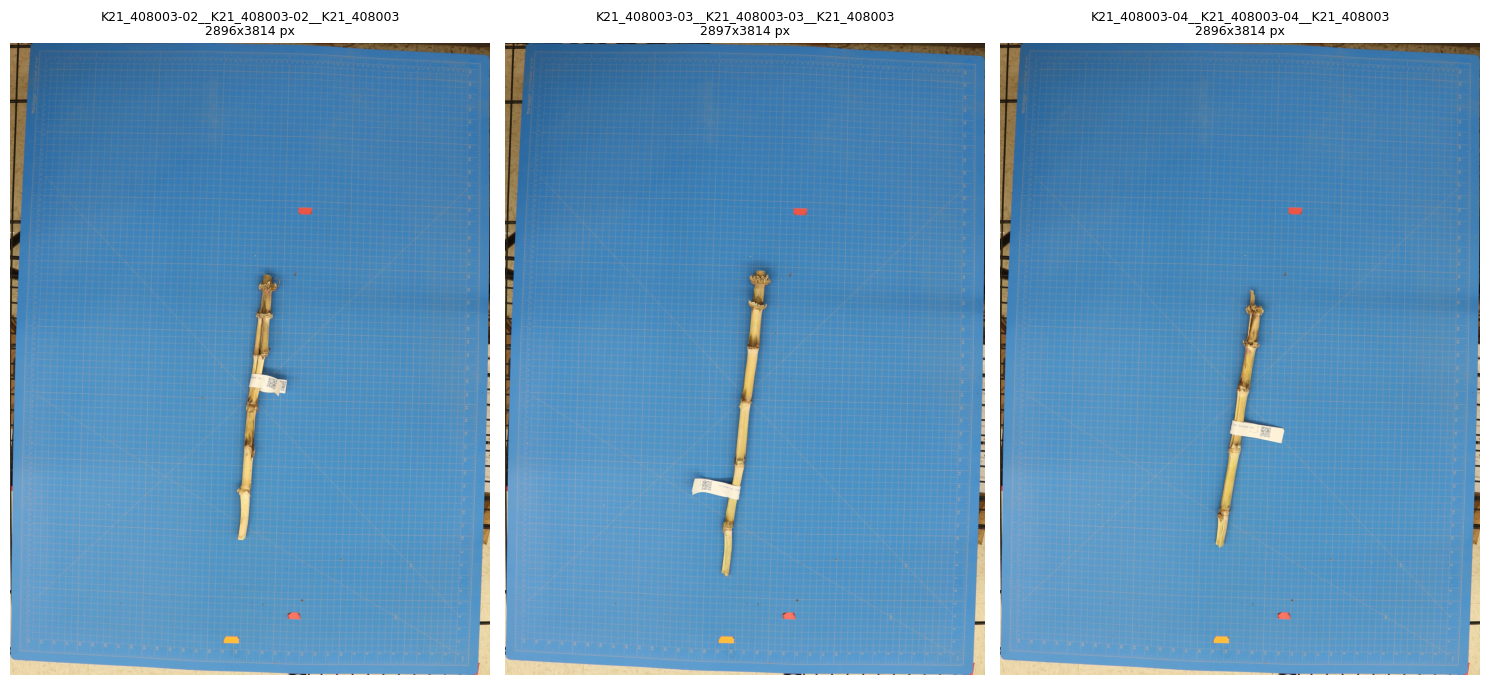

In [ ]:
fig, axes = plt.subplots(1, len(cropped), figsize=(5*len(cropped), 7))
for ax, (path, mat) in zip(np.atleast_1d(axes), cropped.items()):
    ax.imshow(cv2.cvtColor(mat, cv2.COLOR_BGR2RGB))
    ax.set_title(os.path.basename(path)[:40] + f"\n{mat.shape[1]}x{mat.shape[0]} px", fontsize=9)
    ax.axis("off")
plt.tight_layout(); plt.show()

## 5. YOLOv5 node detection with the authors' weight (port of `annotation_function`)

**Purpose:** run the authors' retrained YOLOv5m node detector (`best_nodes.torchscript`) on the cropped mats, exactly as their R helper calls `detect.py`: image size **1632**, NMS IoU threshold **0.2**, CPU device, saving normalized `xywh` labels per image into an `exp/labels/` directory (the format LabelImg and the analysis step consume).

**Implementation note (all points verified on the runtime):** the current `ultralytics/yolov5` hub wrapper cannot load this checkpoint headlessly, so we use the repository exactly the way the authors' `setup_environment.py` does — a shallow git clone of `https://github.com/ultralytics/yolov5` — and call its own `detect.py` machinery (`models.common.DetectMultiBackend`, `utils.general.non_max_suppression`, `utils.general.scale_boxes`) as a library. Three compatibility facts drove the details: (1) the checkpoint weights are FP16, but half-precision CPU inference of this 1632-pixel model is impractically slow, so we run FP32 on CPU (`fp16=False`), consistent with the authors' CPU benchmark (~2.5 s/image on desktop CPUs); (2) the checkpoint's TorchScript anchor grids were traced at a **1632 × 1632 square** input, so each cropped mat is letterboxed to a 1632 × 1632 gray canvas (detect.py pad color 114) instead of a minimum-rectangle fit; (3) NMS uses detect.py defaults with the authors' `--iou-thres 0.2`, and boxes are mapped back to the cropped-image frame via `scale_boxes` before writing the labels.

**YOLOv5による節検出:** 論文の`setup_environment.py`と同じく公式YOLOv5リポジトリを浅いgitクローンで取得し、その`detect.py`と同一の関数（DetectMultiBackend / non_max_suppression / scale_boxes）で同梱の`best_nodes.torchscript`を実行します。重みはFP16で保存されていますが、CPUの半精度推論は極端に遅いためFP32で実行します（著者のCPUベンチマークと整合）。また、TorchScriptのアンカーグリッドは1632×1632の正方形入力でtraceされているため、切り抜き画像を正方形キャンバスへレターボックスしてから推論します。出力は`detect.py --save-txt`と同じ正規化xywhラベルです。

In [ ]:
%pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.9/46.9 kB 580.4 kB/s eta 0:00:00


   ━━━━━━━━━╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.3/1.4 MB 3.2 MB/s eta 0:00:01

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.0/96.0 kB 5.6 MB/s eta 0:00:00


**Clone yolov5 and run node detection:** the next cell clones the official YOLOv5 repository (the same dependency the authors' setup installs), loads the authors' torchscript checkpoint, runs the square-letterbox inference at size 1632 with IoU 0.2 on CPU, and writes one normalized `xywh` label file per cropped stalk image into `exp/labels/`. Expect roughly 7 seconds of inference per image on the Colab CPU. The resolved yolov5 commit is printed for provenance.

In [ ]:
import subprocess, sys, os, glob, shutil, time, torch, cv2

YOLO_DIR = "/content/yolov5"
if not os.path.exists(YOLO_DIR):
    subprocess.check_call(["git", "clone", "--depth", "1",
                           "https://github.com/ultralytics/yolov5", YOLO_DIR],
                          timeout=300)  # same repo the authors' setup_environment.py clones
sys.path.insert(0, YOLO_DIR)
from models.common import DetectMultiBackend
from utils.general import non_max_suppression, scale_boxes

print("yolov5 commit:", subprocess.run(["git", "-C", YOLO_DIR, "rev-parse", "HEAD"],
                                       capture_output=True, text=True).stdout.strip())
model = DetectMultiBackend("best_nodes.torchscript", device=torch.device("cpu"), fp16=False)  # FP32 CPU inference

def letterbox_square(mat, new=1632):
    """detect.py-style letterbox forced to the square canvas the traced grids expect (centered, like scale_boxes assumes)."""
    h, w = mat.shape[:2]
    r = min(new / h, new / w)
    nh, nw = round(h * r), round(w * r)
    canvas = np.full((new, new, 3), 114, np.uint8)   # detect.py default pad color
    top, left = (new - nh) // 2, (new - nw) // 2     # centered padding, matching utils.general.scale_boxes
    canvas[top:top+nh, left:left+nw] = cv2.resize(mat, (nw, nh), interpolation=cv2.INTER_LINEAR)
    return canvas, r

labels_dir = os.path.join("Resized_Outputs", "exp", "labels")
shutil.rmtree(os.path.dirname(labels_dir), ignore_errors=True)
os.makedirs(labels_dir, exist_ok=True)

for path, mat in cropped.items():
    canvas, r = letterbox_square(mat)
    x = torch.from_numpy(canvas).permute(2, 0, 1)[None].float() / 255.0
    t0 = time.time()
    with torch.no_grad():
        y = model(x)
    pred = non_max_suppression(y.float(), conf_thres=0.25, iou_thres=0.2, max_det=1000)[0]
    H, W = mat.shape[:2]
    pred[:, :4] = scale_boxes((canvas.shape[0], canvas.shape[1]), pred[:, :4], (H, W))
    stem = os.path.splitext(os.path.basename(path))[0]
    lines = []
    for x1, y1, x2, y2, conf, cls in pred.tolist():
        xc, yc, bw, bh = (x1+x2)/2/W, (y1+y2)/2/H, (x2-x1)/W, (y2-y1)/H
        lines.append(f"0 {xc:.6f} {yc:.6f} {bw:.6f} {bh:.6f}")
    with open(os.path.join(labels_dir, stem + ".txt"), "w") as f:
        f.write("\n".join(lines))
    print(f"{stem}: {len(lines)} nodes detected in {time.time()-t0:.1f}s")

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.


yolov5 commit: 4add2aff6e3d926586a3eab4659f3b498dd444a1
Loading best_nodes.torchscript for TorchScript inference...


K21_408003-02__K21_408003-02__K21_408003-02_cropped: 6 nodes detected in 5.7s


K21_408003-03__K21_408003-03__K21_408003-03_cropped: 5 nodes detected in 5.6s


K21_408003-04__K21_408003-04__K21_408003-04_cropped: 5 nodes detected in 5.0s


## 6. Internode lengths from node positions (faithful port of `analysis_function`)

**Purpose:** convert normalized node labels to pixel coordinates, sort each stalk top-to-bottom (the authors sort by **descending** `y_pos`), compute Euclidean pixel distance between consecutive nodes, and scale to centimeters with `converter = image_width / (36 in × 2.54 cm/in)` because the cropped mat is 36 inches wide. Internode *x* counts downward from the primary ear-bearing internode, matching the README's output description. Finally each internode's z-score is computed **across stalks** and `|z| ≥ 2` flags an image whose annotation may need manual verification (the authors' LabelImg step, which is GUI-only and therefore performed by inspection here).

**節間長の計算:** 正規化座標をピクセルへ戻し、茎ごとに上から並べ替え（降順 y）、連続する節間のユークリッド距離をとり、`converter = 画像幅 / 91.44 cm`でcm換算します。節間番号は一次えい花節から下方へ数えます（READMEの仕様）。Zスコアは茎間で計算し、|z|≥2 を外れ値フラグとします。

In [ ]:
from math import sqrt

MAT_WIDTH_CM = 36 * 2.54  # authors: blue backmat is 36 inches wide (helper_functions.R)

records, dims = [], {}
for path, mat in cropped.items():
    stem = os.path.splitext(os.path.basename(path))[0]
    dims[stem] = mat.shape[:2]
    H, W = mat.shape[:2]
    with open(os.path.join(labels_dir, stem + ".txt")) as f:
        nodes = [ln.split() for ln in f if ln.strip()]
    df = pd.DataFrame(nodes, columns=["cls", "x_pos", "y_pos", "w", "h"]).astype(float)  # detect.py --save-txt format: class xc yc w h (normalized)
    df = df.sort_values("y_pos", ascending=False)          # authors: arrange(., -y_pos)
    df["x_pos"] = (df["x_pos"] * W).round()
    df["y_pos"] = (df["y_pos"] * H).round()
    df.insert(0, "annotation_id", stem)
    df["converter"] = W / MAT_WIDTH_CM                     # pixels per cm
    df["Node"] = range(1, len(df) + 1)
    df["Internode"] = df["Node"] - 1
    df["Total_Internodes"] = len(df) - 1
    records.append(df)

ann = pd.concat(records, ignore_index=True)
ann["Pixel_Distance"] = [
    sqrt((ann.x_pos[i]-ann.x_pos[i-1])**2 + (ann.y_pos[i]-ann.y_pos[i-1])**2)
    if i > 0 and ann.annotation_id[i] == ann.annotation_id[i-1] else np.nan
    for i in ann.index
]
ann = ann[ann["Pixel_Distance"].notna()].copy()
ann["Distance"] = ann["Pixel_Distance"] / ann["converter"]  # cm

# authors' z-score across stalks per internode index, outlier if |z| >= 2
grp = ann.groupby("Internode")["Distance"]
ann["z_score"] = (ann["Distance"] - grp.transform("mean")) / grp.transform("std")
ann["outliers"] = ann["z_score"] >= 2

# per-stalk summary like the README's data_output.xlsx columns
summary = (
    ann.groupby("annotation_id")
       .agg(Total_Internodes=("Internode", "count"),
            Sum_Internodes_cm=("Distance", "sum"),
            max_z_score=("z_score", lambda s: s.abs().max()))
       .reset_index()
)
summary["outliers"] = ann.groupby("annotation_id")["outliers"].any().values
summary["image_width_px"] = [dims[s][1] for s in summary["annotation_id"]]
summary["converter_px_per_cm"] = ann.groupby("annotation_id")["converter"].first().values
summary

,annotation_id,Total_Internodes,Sum_Internodes_cm,max_z_score,outliers,image_width_px,converter_px_per_cm
0,K21_408003-02__K21_408003-02__K21_408003-02_cr...,5,39.002520,1.154239,False,2896,31.671041
1,K21_408003-03__K21_408003-03__K21_408003-03_cr...,4,42.466331,0.826071,False,2897,31.681977
2,K21_408003-04__K21_408003-04__K21_408003-04_cr...,4,38.777893,1.112845,False,2896,31.671041


### 6b. Per-internode length table

**Purpose:** show the wide per-stalk internode table the pipeline produces (columns `Internode_1..n`, cm from the ear-bearing internode down), then export it as `data_output.csv` (a CSV stand-in for the authors' `data_output.xlsx`, which needs the extra `openxlsx` dependency).

**節間長の表:** 著者のパイプラインと同じ「茎ごと × 節間ごと」のワイド表を作成し、`data_output.csv`として保存します（xlsxの代わりにCSV。単位はcm）。

In [ ]:
wide = ann.pivot_table(index="annotation_id", columns="Internode", values="Distance")
wide.columns = [f"Internode_{c}" for c in wide.columns]
wide = wide.round(2).join(summary.set_index("annotation_id"))
display(wide)
wide.to_csv("data_output.csv")
print("saved data_output.csv")

,Internode_1,Internode_2,Internode_3,Internode_4,Internode_5,...,Sum_Internodes_cm,max_z_score,outliers,image_width_px,converter_px_per_cm
annotation_id,,,,,,,,,,,
K21_408003-02__K21_408003-02__K21_408003-02_cropped,8.35,7.82,9.86,7.46,5.51,...,39.002520,1.154239,False,2896,31.671041
K21_408003-03__K21_408003-03__K21_408003-03_cropped,12.49,11.67,10.42,7.88,NaN,...,42.466331,0.826071,False,2897,31.681977
K21_408003-04__K21_408003-04__K21_408003-04_cropped,12.21,11.80,8.42,6.34,NaN,...,38.777893,1.112845,False,2896,31.671041


saved data_output.csv


### 6c. Annotated result figure

**Purpose:** overlay the detected node positions and the computed internode lengths (cm) on each cropped stalk image — the visual check the authors perform in LabelImg, rendered here as saved figure output. Nodes are drawn top-to-bottom in detection order; labels give each internode length between consecutive nodes.

**結果の重畳表示:** 検出した節位置と、隣接節間の計算距離（cm）を切り抜き画像へ重畳します。LabelImgでの確認作業に相当する可視化です。

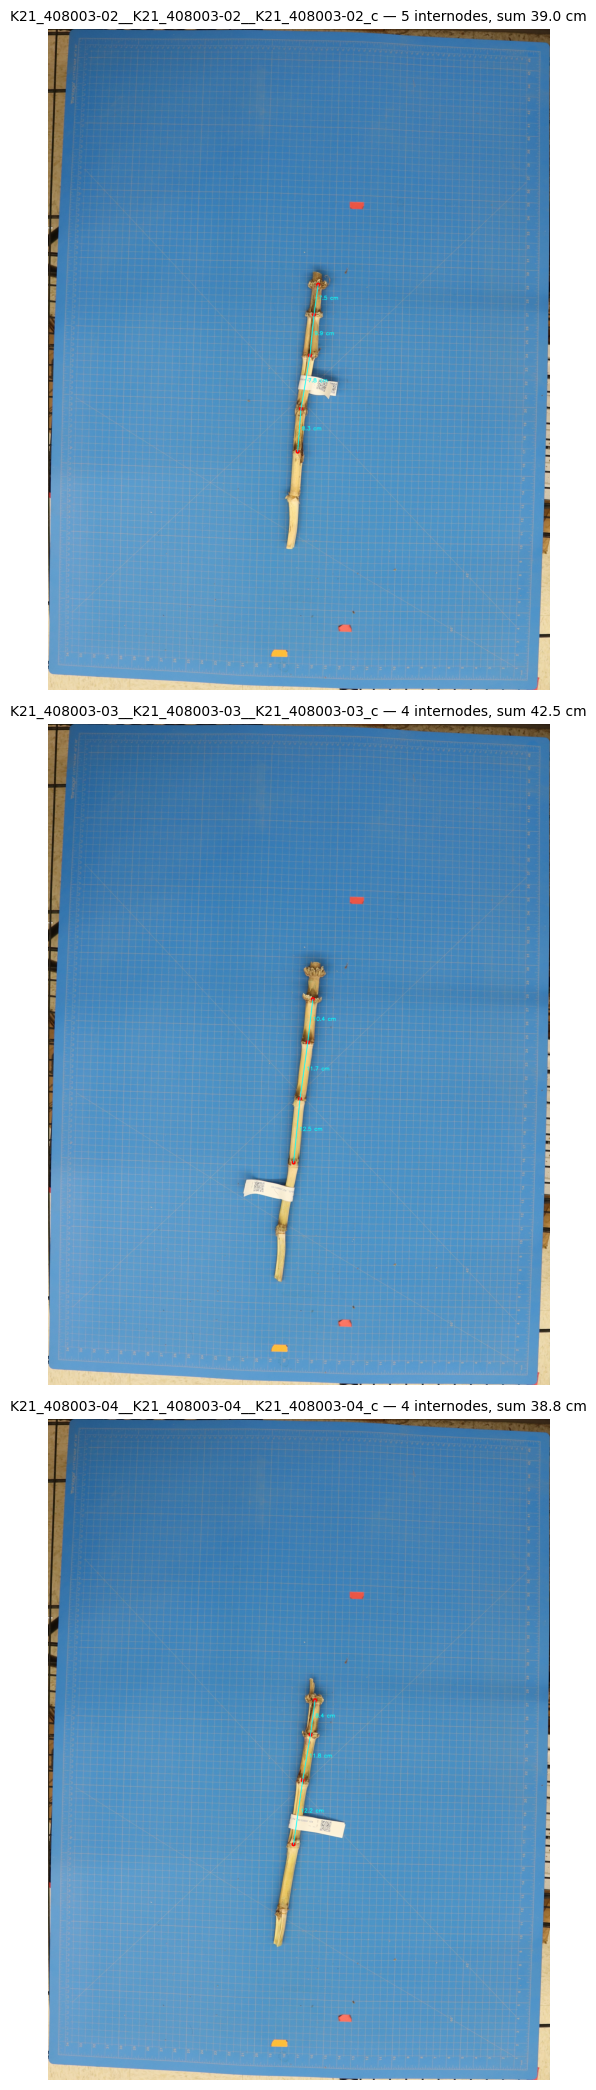

In [ ]:
fig, axes = plt.subplots(len(cropped), 1, figsize=(8, 7*len(cropped)))
axes = np.atleast_1d(axes)
for ax, (path, mat) in zip(axes, cropped.items()):
    stem = os.path.splitext(os.path.basename(path))[0]
    vis = cv2.cvtColor(mat.copy(), cv2.COLOR_BGR2RGB)
    d = ann[ann.annotation_id == stem].sort_values("Node")
    for _, row in d.iterrows():
        cv2.circle(vis, (int(row.x_pos), int(row.y_pos)), 12, (255, 0, 0), -1)
    for i in range(1, len(d)):
        a, b = d.iloc[i-1], d.iloc[i]
        cv2.line(vis, (int(a.x_pos), int(a.y_pos)), (int(b.x_pos), int(b.y_pos)), (0, 255, 255), 3)
        cv2.putText(vis, f"{a.Distance:.1f} cm",
                    (int((a.x_pos+b.x_pos)/2)+15, int((a.y_pos+b.y_pos)/2)),
                    cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 255, 255), 2, cv2.LINE_AA)
    ax.imshow(vis)
    ax.set_title(f"{stem[:45]} — {d.Total_Internodes.iloc[0]} internodes, sum {d.Distance.sum():.1f} cm", fontsize=10)
    ax.axis("off")
plt.tight_layout()
plt.savefig("internode_results.png", dpi=110, bbox_inches="tight")
plt.show()

## 7. Interpretation and limitations

**What was executed:** the authors' internode-measurement chain — mat crop → YOLOv5m node detection (`best_nodes.torchscript`, 1632-pixel inference, NMS IoU 0.2) → pixel-to-cm conversion via the 36-inch mat width → per-internode lengths with cross-stalk z-score outlier flags — on three repository example stalks, all inside this notebook.

**Limitations / 論文・著者コードとの違い:**
- The R conversion step (`helper_functions.R:analysis_function`) is re-implemented in Python with identical arithmetic (rounding, descending-y ordering, Euclidean distance, `converter = width/91.44`); the R Shiny dashboard, LabelImg GUI verification, and Excel export are replaced by headless equivalents (CSV export + the overlay figure above). **This is an AI-assisted headless port; the authors did not provide this notebook.**
- Detection details verified necessary on today's runtime but differing from the authors' 2023 environment: FP32 (not FP16) inference and a forced 1632 × 1632 square letterbox (the checkpoint's traced grids are square and its weights are FP16); detection runs from a shallow clone of current `ultralytics/yolov5` master through the same `detect.py` functions the authors call.
- Only 3 of 48 example images are used, so z-scores are indicative, not a validation of the authors' 99%-correct verified-annotation claim.
- No quantitative reference values are published for these images; results are shown as computed, not compared against a ground truth.
- The paper's remaining phases (DARLING, puncture, bending, chemistry) require instruments and non-deposited data and are intentionally out of scope.

**参考:** 論文: Tabaracci et al., MethodsX 12 (2024) 102562 (CC BY)。コード: github.com/nbo245/InterMeas（commit f176cc0）。本notebookは学術的な表示・デモ目的の利用であり、リポジトリ内容を再配布しません。